## ViT-based defect classification with visual interpretability using attention and Grad-CAM

In [ ]:
import sys
from pathlib import Path

# Path setup
project_root = Path.cwd().parent
sys.path.append(str(project_root))

# Seed 
from src.utils.seed import set_seed
set_seed(42)

# Imports
import torch
from src.data_operations.dataset import build_dataloaders
from src.data_operations.transforms import get_train_transforms, get_val_transforms

Seed set to 42


In [3]:
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0))

Torch version: 2.10.0+cu128
CUDA available: True
GPU name: NVIDIA GeForce RTX 4070 Ti SUPER


In [4]:
from src.models.transformer.vit import build_vit

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vit_model = build_vit(num_classes=6)
vit_model = vit_model.to(device)

vit_model.print_trainable_layers()

params = vit_model.count_parameters()
print(f"Trainable: {params['trainable']:,}")
print(f"Total:     {params['total']:,}")


Layer                Status
--------------------------------
conv_proj            frozen
encoder              frozen
heads                trainable
Trainable: 4,614
Total:     85,803,270


In [5]:
from src.data_operations.dataset import build_dataloaders
from src.data_operations.transforms import get_train_transforms, get_val_transforms

splits_root = project_root / "data" / "splits"

train_loader, val_loader, test_loader = build_dataloaders(
    root            = splits_root,
    train_transform = get_train_transforms(),
    val_transform   = get_val_transforms(),
    batch_size      = 32,
    num_workers     = 4,
    pin_memory      = True,
)
print(train_loader)

In [ ]:
num_epochs = 10
from src.training.train import train, evaluate

history = train(
    model = vit_model, 
    train_loader = train_loader, 
    val_loader = val_loader, 
    num_epochs = num_epochs)

Epoch 1/10
  Train — loss: 0.6570  acc: 0.8732
  Val   — loss: 0.2810  acc: 0.9815
Epoch 2/10
  Train — loss: 0.1487  acc: 0.9856
  Val   — loss: 0.1555  acc: 0.9852
Epoch 3/10
  Train — loss: 0.0893  acc: 0.9904
  Val   — loss: 0.1065  acc: 0.9963
Epoch 4/10
  Train — loss: 0.0627  acc: 0.9968
  Val   — loss: 0.0835  acc: 0.9963
Epoch 5/10
  Train — loss: 0.0479  acc: 0.9992
  Val   — loss: 0.0686  acc: 0.9963
Epoch 6/10
  Train — loss: 0.0412  acc: 0.9968
  Val   — loss: 0.0590  acc: 0.9963
Epoch 7/10
  Train — loss: 0.0348  acc: 0.9984
  Val   — loss: 0.0550  acc: 0.9889
Epoch 8/10
  Train — loss: 0.0285  acc: 0.9992
  Val   — loss: 0.0432  acc: 0.9963
Epoch 9/10
  Train — loss: 0.0248  acc: 0.9984
  Val   — loss: 0.0432  acc: 0.9963
Epoch 10/10
  Train — loss: 0.0213  acc: 1.0000
  Val   — loss: 0.0393  acc: 0.9963


In [7]:
test_loss, test_acc = evaluate(vit_model, test_loader)

loss: 0.0266  acc: 1.0000


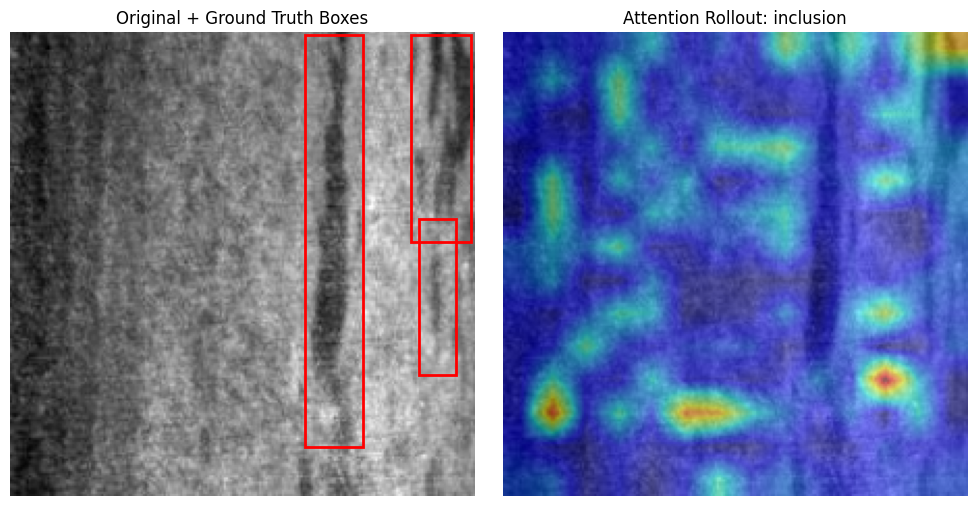

In [ ]:
from src.interpretability.attention_viz import AttentionRollout
import random

idx    = random.randint(0, len(test_loader.dataset) - 1)

rollout = AttentionRollout(vit_model)

sample  = test_loader.dataset[idx]
boxes   = test_loader.dataset.get_boxes(sample["image_path"])
classes = test_loader.dataset.classes

rollout.visualize(sample, classes, boxes=boxes)

### Attention isn't great for interpretability

## Let's try GradCAM

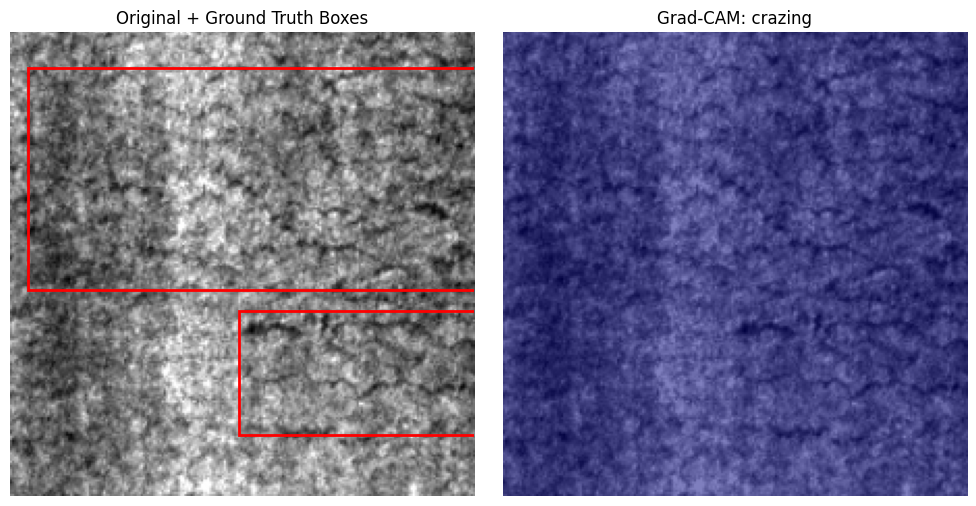

In [9]:
from src.interpretability.gradcam import GradCAM
import random

idx    = random.randint(0, len(test_loader.dataset) - 1)

cam_vit = GradCAM(vit_model,target_layer=vit_model.model.encoder.layers[-1])

sample  = test_loader.dataset[idx]
boxes   = test_loader.dataset.get_boxes(sample["image_path"])
classes = test_loader.dataset.classes

cam_vit.visualize(sample, classes, boxes=boxes)


── crazing ──


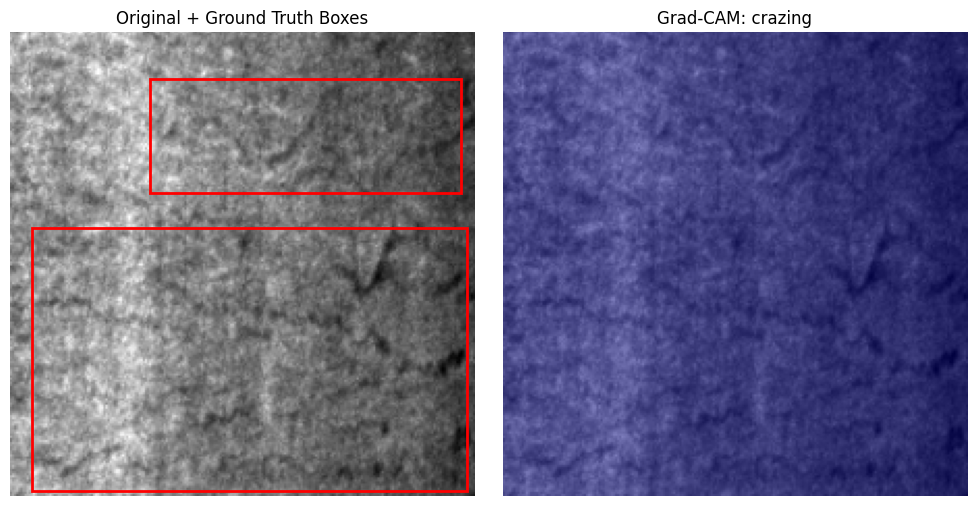


── inclusion ──


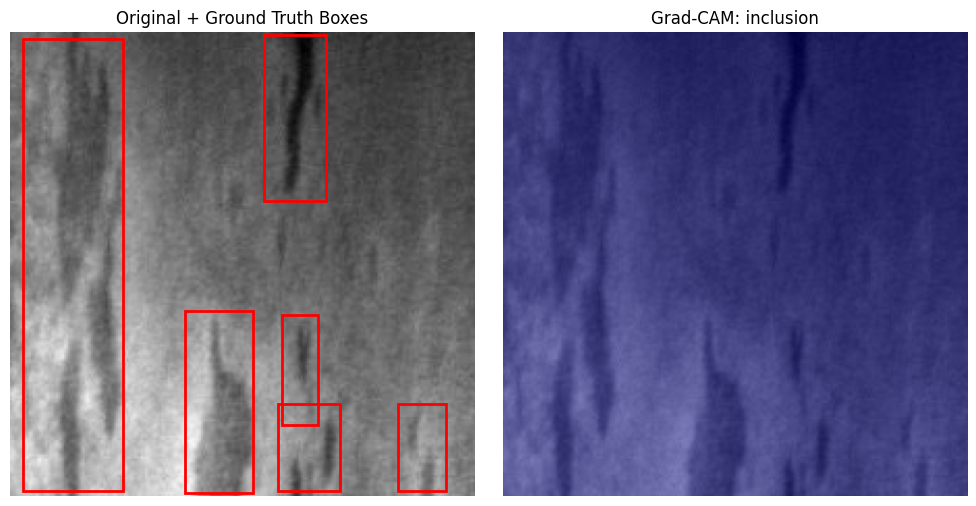


── patches ──


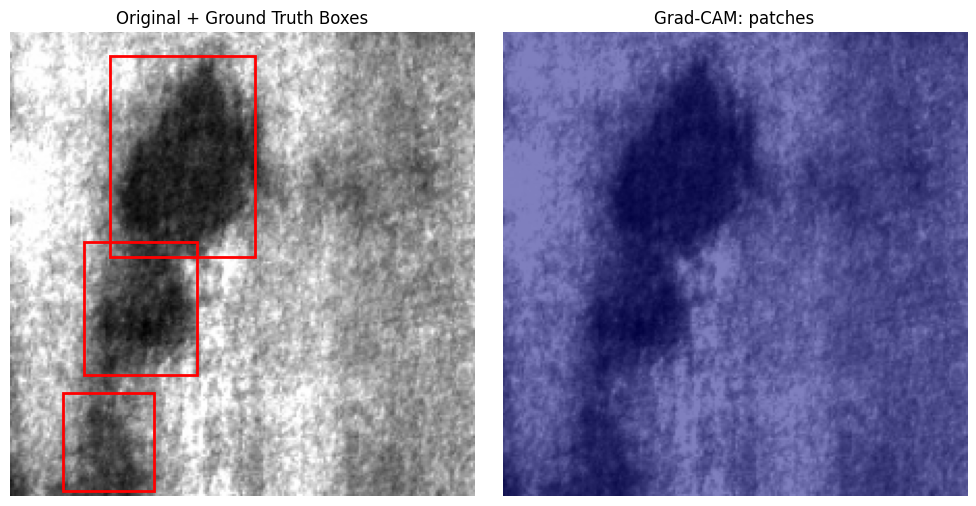


── pitted_surface ──


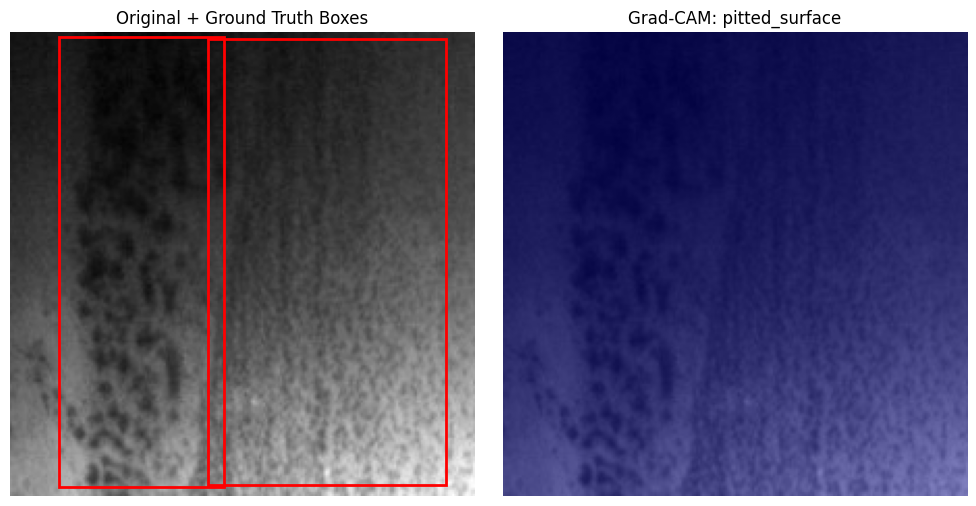


── rolled-in_scale ──


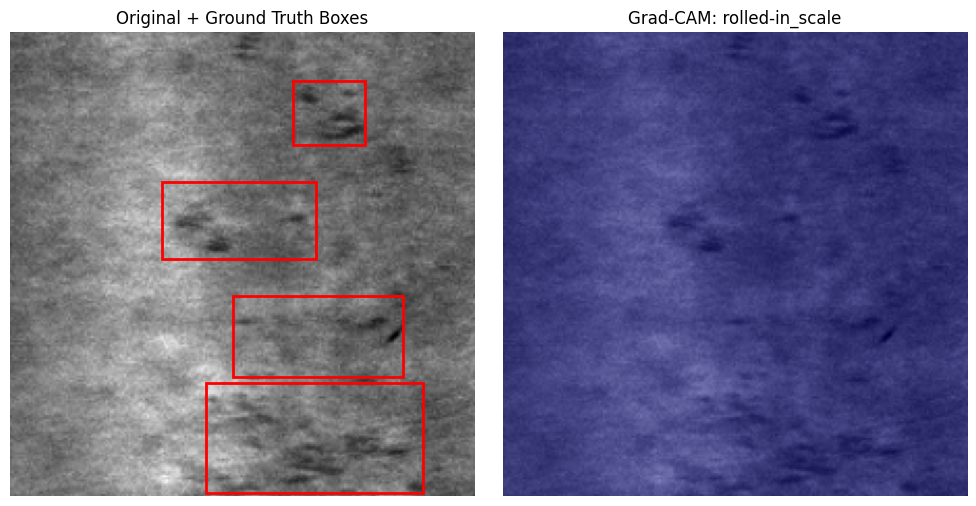


── scratches ──


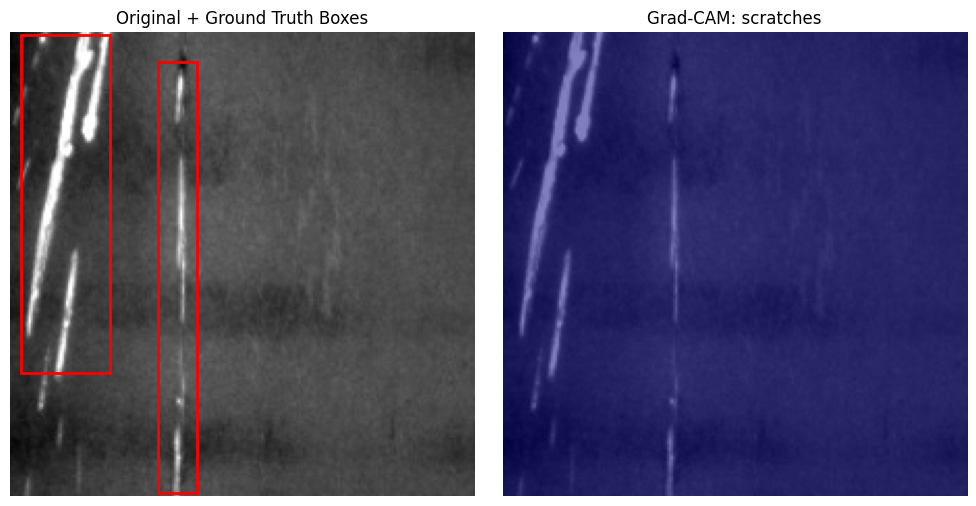

In [10]:
examples = {}

for idx in range(len(test_loader.dataset)):
    sample     = test_loader.dataset[idx]
    class_name = test_loader.dataset.classes[sample["label"]]

    if class_name not in examples:
        examples[class_name] = idx

    # stop early once all 6 classes found
    if len(examples) == len(test_loader.dataset.classes):
        break

# visualise one per class
for class_name, idx in examples.items():
    sample  = test_loader.dataset[idx]
    boxes   = test_loader.dataset.get_boxes(sample["image_path"])
    classes = test_loader.dataset.classes
    print(f"\n── {class_name} ──")
    cam_vit.visualize(sample, classes, boxes=boxes)

## Grad-CAM Analysis

Grad-CAM does not produce meaningful heatmaps for this frozen ViT. The method requires gradients to flow back through the network to the target layer — but with a fully frozen backbone, the gradient signal is effectively zero. The frozen weights were optimised for ImageNet, not defect localisation, so they carry no task-specific spatial information for Grad-CAM to surface.

Two fixes were attempted without success:
- Setting `requires_grad_(True)` on the input image tensor — gradients remained zero
- Temporarily enabling gradients on the last encoder block during the backward pass — gradients became non-zero but the resulting heatmap was uniformly near-zero after ReLU, indicating the frozen features carry no spatial class signal

Meaningful interpretability for this ViT would require either full fine-tuning or a self-supervised backbone such as DINO, which develops task-specific attention patterns during pretraining. This result is consistent with published findings that frozen transformer backbones do not produce reliable spatial explanations.